# Monte Carlo prediction intervals with provable coverage validation

The original simulation constructs prediction intervals for a Gaussian linear
model. The audit below adds finite-sample confidence bounds for the **actual
coverage probability of that implemented procedure**, including its finite inner
Monte Carlo budget. Run this notebook from the repository directory so that
`validation.py` can be imported.

The nominal prediction-interval level (for example, 95%) and the confidence in
our audit (also chosen as 95% here) are distinct quantities. An observed coverage
near 95% does not by itself certify coverage of at least 95%.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from validation import coverage_certificate

def generate_training_data(
    n=50,
    beta0=1.0,
    beta1=2.0,
    sigma=1.0
):
    x = np.random.normal(0, 1, n)

    noise = np.random.normal(
        0,
        sigma,
        n
    )

    y = beta0 + beta1 * x + noise

    return x, y



In [2]:
def fit_linear_regression(x, y):

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    Sxx = np.sum(
        (x - x_mean) ** 2
    )

    Sxy = np.sum(
        (x - x_mean) *
        (y - y_mean)
    )

    beta1_hat = Sxy / Sxx

    beta0_hat = (
        y_mean -
        beta1_hat * x_mean
    )

    return beta0_hat, beta1_hat

In [3]:
def predict(beta0_hat,beta1_hat,x_star):
    return(beta0_hat+beta1_hat*x_star)


In [4]:
def monte_carlo_predictive_distribution(
    x_star,
    R=5000,
    n=50,
    beta0=1.0,
    beta1=2.0,
    sigma=1.0
):

    predictions = []

    for _ in range(R):

       
        x_train, y_train = generate_training_data(
            n=n,
            beta0=beta0,
            beta1=beta1,
            sigma=sigma
        )

     

        beta0_hat, beta1_hat = fit_linear_regression(
            x_train,
            y_train
        )

      

        y_hat = predict(
            beta0_hat,
            beta1_hat,
            x_star
        )

       
        future_noise = np.random.normal(
            0,
            sigma
        )

       

        y_star = y_hat + future_noise

        predictions.append(y_star)

    return np.array(predictions)

def monte_carlo_prediction_interval(x_star,confidence=0.95,R=5000,n=50,beta0=1.0,beta1=2.0,sigma=1.0):
    samples = monte_carlo_predictive_distribution(
        x_star=x_star,
        R=R,
        n=n,
        beta0=beta0,
        beta1=beta1,
        sigma=sigma
    )

    alpha = 1 - confidence

    lower = np.quantile(
        samples,
        alpha / 2
    )

    upper = np.quantile(
        samples,
        1 - alpha / 2
    )

    median = np.quantile(
        samples,
        0.5
    )

    return lower, median, upper, samples

np.random.seed(42)

lower, median, upper, samples = (
    monte_carlo_prediction_interval(
        x_star=1.0,
        confidence=0.95,
        R=5000
    )
)

print("Median prediction:", median)
print("95% PI:", (lower, upper))

Median prediction: 2.9939620579830977
95% PI: (np.float64(0.9379697988121196), np.float64(4.970042216511043))


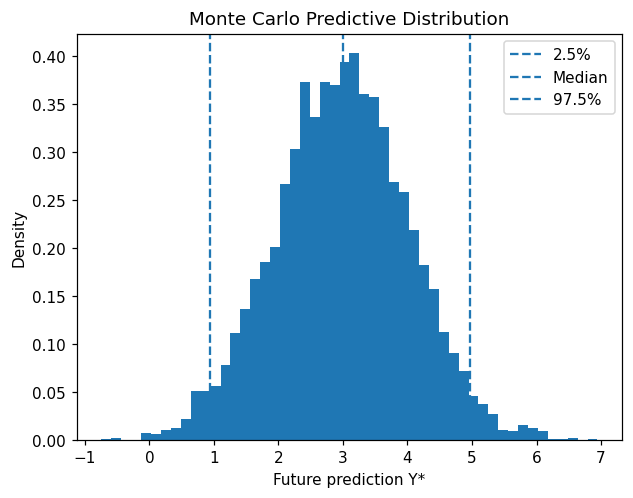

In [5]:
plt.hist(
    samples,
    bins=50,
    density=True
)

plt.axvline(
    lower,
    linestyle="--",
    label="2.5%"
)

plt.axvline(
    median,
    linestyle="--",
    label="Median"
)

plt.axvline(
    upper,
    linestyle="--",
    label="97.5%"
)

plt.xlabel("Future prediction Y*")
plt.ylabel("Density")
plt.title("Monte Carlo Predictive Distribution")
plt.legend()

plt.show()

## What is being validated?

Fix `x_star`, `n`, `R`, the true simulator parameters, and a nominal level before
the audit. One outer experiment independently constructs an interval $I_i$ using
`monte_carlo_prediction_interval`, draws a fresh true future observation $Y_i$,
and records
\[
Z_i=\mathbf{1}\{Y_i\in I_i\},\qquad
p=\Pr\{Y_i\in I_i\},\qquad
\widehat p=\frac{1}{N}\sum_{i=1}^N Z_i.
\]
Under independent, identically distributed repetitions, the indicators are
Bernoulli with mean $p$. Here $N$ is `num_experiments`, **not** `R` and not
`num_experiments * R`. The `R` inner draws construct one random interval; their
finite-sample error is already included in the procedure being audited.

For $m$ claims specified before seeing results and family failure probability
$\delta$, write $c=\log(2m/\delta)$. The Hoeffding interval is
\[
[L,U]=\left[\max\{0,\widehat p-\sqrt{c/(2N)}\},
             \min\{1,\widehat p+\sqrt{c/(2N)}\}\right].
\]
The default, sharper Bernoulli Chernoff interval inverts
\[
N\,\operatorname{kl}(\widehat p\Vert q)\le c,\qquad
\operatorname{kl}(a\Vert q)
=a\log\frac{a}{q}+(1-a)\log\frac{1-a}{1-q},
\]
with the usual continuous endpoint conventions. Its smallest and largest
admissible $q\in[0,1]$ are $L$ and $U$. Each one-sided Chernoff or Hoeffding tail
costs at most $\delta/(2m)$; a union bound over both tails and all $m$ claims gives
\[
\Pr\{L_j\le p_j\le U_j\text{ for every }j=1,\ldots,m\}\ge 1-\delta.
\]
Independence **between levels** is not required for this union bound; independent
repetitions **within each level** are required for these Bernoulli bounds.

The target is certified only when `lower >= target_coverage`; `below_target`
means `upper < target_coverage`; otherwise the result is `inconclusive`.
This is a repeated-audit probability guarantee, not a posterior probability
that $p$ lies in the reported interval.

**Scope and assumptions.** This notebook retains the original simulator:
training data are resampled inside each inner Monte Carlo draw, and the true
regression/noise parameters are supplied to the simulator. Consequently $p$ is
coverage averaged over this simulation procedure's interval construction and
future observation, at the chosen `x_star`. It does not certify an individual
realized interval, conditional coverage at every covariate, or coverage under
an unknown real-world distribution. Parameters, sample sizes, targets, and the
family of claims must be fixed independently of audit outcomes. After tuning
using audit results, use fresh independent audit data and an appropriate new
confidence budget. These fixed-sample bounds do not allow repeatedly peeking
and stopping as soon as certification succeeds. The random seed is set once
for reproducibility; the probability statement assumes ideal independent
random draws, as usual for Monte Carlo validation.


In [6]:
def coverage_test(
    num_experiments=1000,
    confidence=0.95,
    R=1000,
    n=50,
    beta0=1.0,
    beta1=2.0,
    sigma=1.0,
    x_star=1.0,
    *,
    return_certificate=False,
    delta=0.05,
    num_claims=1,
    method="kl",
    target_coverage=None
):
    """Audit independent repetitions of the existing simulation protocol.

    Return the original empirical-coverage float by default. Set
    return_certificate=True to obtain finite-sample coverage bounds.
    """
    if (
        isinstance(num_experiments, (bool, np.bool_))
        or not isinstance(num_experiments, (int, np.integer))
        or num_experiments <= 0
    ):
        raise ValueError("num_experiments must be a positive integer")

    covered = 0

    for _ in range(num_experiments):

        # -------------------------
        # Construct MC prediction interval
        # -------------------------

        lower, median, upper, _ = (
            monte_carlo_prediction_interval(
                x_star=x_star,
                confidence=confidence,
                R=R,
                n=n,
                beta0=beta0,
                beta1=beta1,
                sigma=sigma
            )
        )

        # -------------------------
        # Generate TRUE future observation
        # -------------------------

        true_mean = (
            beta0 +
            beta1 * x_star
        )

        y_star = (
            true_mean +
            np.random.normal(
                0,
                sigma
            )
        )

        # -------------------------
        # Coverage test
        # -------------------------

        if lower <= y_star <= upper:
            covered += 1

    empirical_coverage = (
        covered / num_experiments
    )

    if return_certificate:
        return coverage_certificate(
            successes=covered,
            trials=num_experiments,
            delta=delta,
            num_claims=num_claims,
            method=method,
            target_coverage=target_coverage,
        )
    return empirical_coverage

In [7]:
# Declare the complete audit family and protocol before observing results.
levels = [0.80, 0.90, 0.95, 0.99]
family_delta = 0.05
num_experiments = 1000  # Independent outer coverage indicators per level.
R = 1000               # Inner MC draws used to construct each interval.
method = "kl"          # Use "hoeffding" for the additive Hoeffding bound.

# Seed once for reproducibility; never reset the seed inside repetitions.
np.random.seed(20260918)

certificates = []
empirical = []
for confidence in levels:
    certificate = coverage_test(
        num_experiments=num_experiments,
        confidence=confidence,
        R=R,
        return_certificate=True,
        delta=family_delta,
        num_claims=len(levels),
        method=method,
        target_coverage=confidence
    )
    certificates.append(certificate)
    empirical.append(certificate.empirical_coverage)
    print(
        f"Nominal={confidence:.2f}, "
        f"covered={certificate.successes}/{certificate.trials}, "
        f"empirical={certificate.empirical_coverage:.4f}, "
        f"bounds=[{certificate.lower:.4f}, {certificate.upper:.4f}], "
        f"status={certificate.status}"
    )

print(
    f"All {len(levels)} coverage bounds are simultaneous at "
    f"{1 - family_delta:.0%} audit confidence ({method} method)."
)


Nominal=0.80, covered=793/1000, empirical=0.7930, bounds=[0.7503, 0.8318], status=inconclusive
Nominal=0.90, covered=896/1000, empirical=0.8960, bounds=[0.8626, 0.9241], status=inconclusive
Nominal=0.95, covered=953/1000, empirical=0.9530, bounds=[0.9286, 0.9713], status=inconclusive
Nominal=0.99, covered=989/1000, empirical=0.9890, bounds=[0.9750, 0.9965], status=inconclusive
All 4 coverage bounds are simultaneous at 95% audit confidence (kl method).


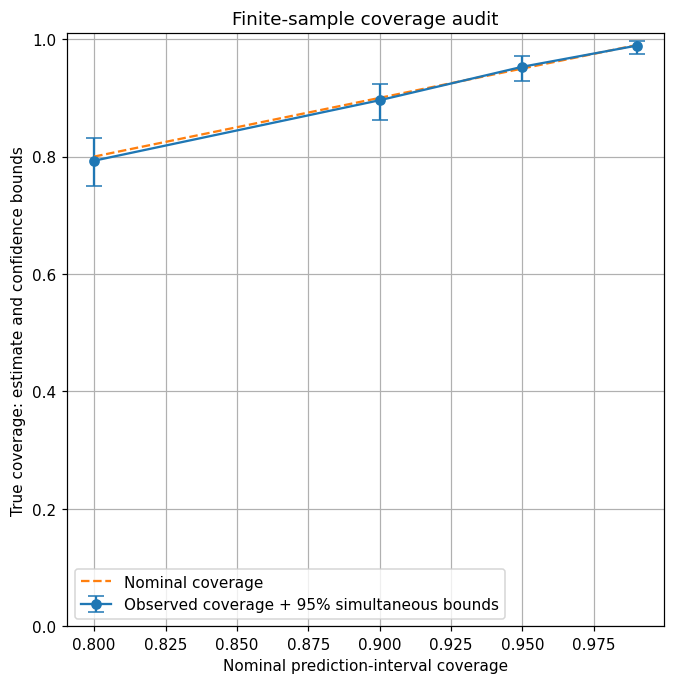

In [8]:
plt.figure(figsize=(7, 7))
error_bars = np.array([
    [c.empirical_coverage - c.lower for c in certificates],
    [c.upper - c.empirical_coverage for c in certificates]
])
plt.errorbar(
    levels,
    empirical,
    yerr=error_bars,
    fmt="o-",
    capsize=5,
    label=f"Observed coverage + {1 - family_delta:.0%} simultaneous bounds"
)

plt.plot(
    levels,
    levels,
    linestyle="--",
    label="Nominal coverage"
)
plt.xlabel("Nominal prediction-interval coverage")
plt.ylabel("True coverage: estimate and confidence bounds")
plt.ylim(0, 1.01)
plt.title("Finite-sample coverage audit")
plt.legend()
plt.grid(True)

plt.show()


## Reading the audit

The four predeclared levels share one $\delta=0.05$ budget. All four bounds hold
simultaneously with probability at least 95% under the assumptions above. A
single-level audit may use `num_claims=1`; the sweep must use
`num_claims=len(levels)`. Adding more settings or distinct coverage probabilities to the reported family
requires including them in the multiplicity budget before auditing.

With 1,000 outer experiments and four claims, the two-sided Hoeffding margin is
$\sqrt{\log(160)/2000}\approx0.0504$. The KL bound is usually substantially
narrower near coverage 0 or 1. Even so, a procedure whose true coverage is exactly
its nominal level will usually have an inconclusive test of the claim that
coverage is at least nominal. If a tolerance is scientifically acceptable,
choose a smaller target **before** collecting audit data; do not lower the target
after inspecting the results. For this notebook the target remains the nominal
level, so an inconclusive result is reported honestly.

Existing calls such as `coverage_test(num_experiments=1000)` still return a float.
Use `return_certificate=True` to obtain integer success counts, confidence bounds,
and the certification status.
